# Task 12 — K-Means Clustering with Elbow Method

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:

df = pd.read_csv("../data/loan_data.csv")
df.dropna(inplace=True)
df = df.drop_duplicates().reset_index(drop=True)

features = ['income', 'credit_score', 'loan_amount', 'employment_years']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Data ready. Shape:", X_scaled.shape)

Data ready. Shape: (270, 4)


### Elbow Method — find the best k

In [3]:
inertias = []
K = range(1, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

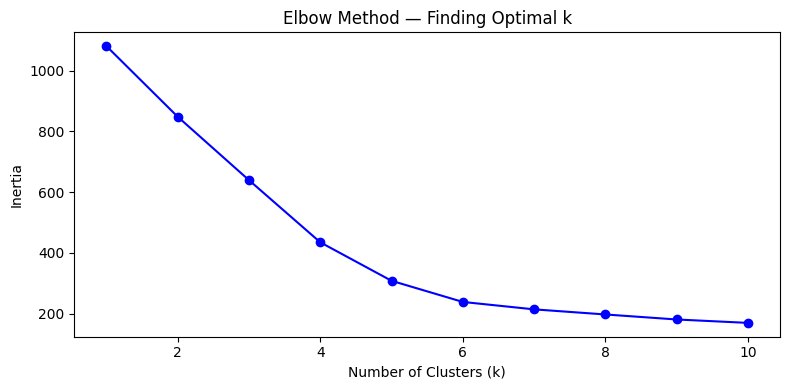

In [7]:

plt.figure(figsize=(8, 4))
plt.plot(K, inertias, 'bo-')
plt.title("Elbow Method — Finding Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.tight_layout()
plt.savefig("elbow.png")
plt.show()


### the optimal number of clusters (k) is likely 3 or 4. 



In [8]:
km = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X_scaled)

print("Cluster sizes:")
print(df['cluster'].value_counts().sort_index())

print("Cluster profiles:")
print(df.groupby('cluster')[features].mean().round(1))

Cluster sizes:
cluster
0    134
1    135
2      1
Name: count, dtype: int64
Cluster profiles:
           income  credit_score  loan_amount  employment_years
cluster                                                       
0         57572.3         606.7      28718.7              14.2
1         58593.7         556.3      37634.6               4.7
2        950000.0         409.0      52198.0              13.0


### Scatter plot — clusters

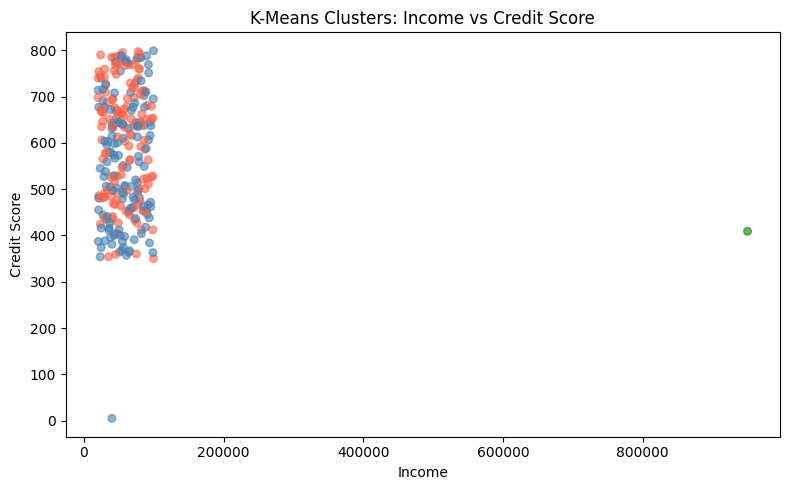

In [9]:
colors = df['cluster'].map({0:'tomato', 1:'steelblue', 2:'green'})

plt.figure(figsize=(8, 5))
plt.scatter(df['income'], df['credit_score'], c=colors, alpha=0.6, s=30)
plt.title("K-Means Clusters: Income vs Credit Score")
plt.xlabel("Income")
plt.ylabel("Credit Score")
plt.tight_layout()
plt.savefig("kmeans_clusters.png")
plt.show()

#### since the distribution of given dataset isnt sperically separated(which is the basic requirement for k means), same procedure will be applied in synthetically generated data for the sake of demonstration of concept.


In [ ]:
from sklearn.datasets import make_blobs
# Generate Synthetic Data
# We create 300 samples across 4 distinct centers
X1, y1 = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# 2. Compute Inertia for different values of k
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X1)
    inertia.append(kmeans.inertia_)



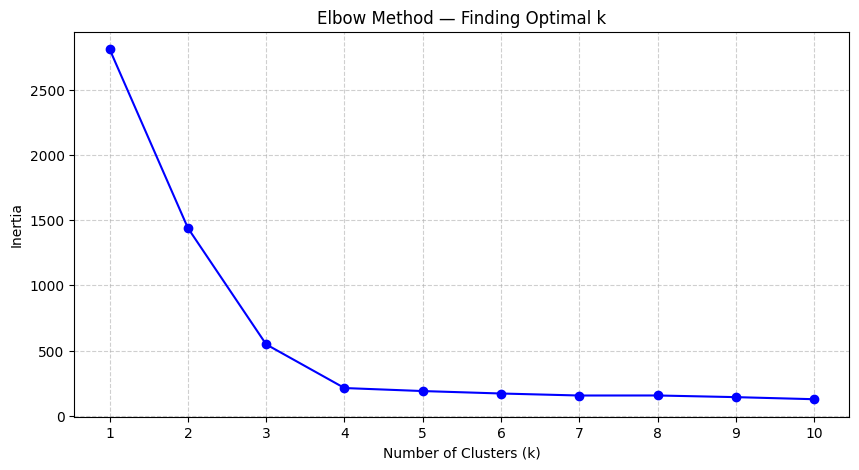

In [16]:

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, marker='o', linestyle='-', color='blue')
plt.title('Elbow Method — Finding Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

the elbow appears at k=4, which matches our synthetic data generation with 4 centers.

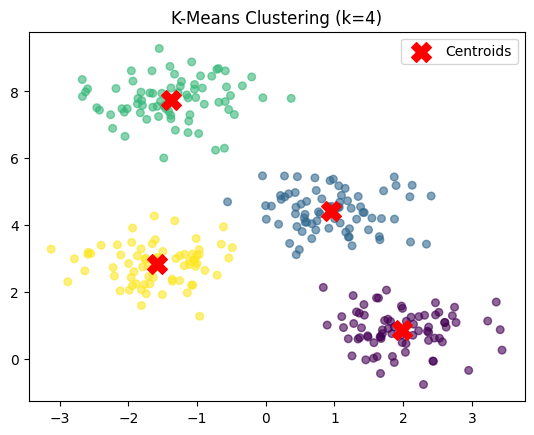

In [18]:
# cluster visualization with k=4
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
y_pred = kmeans.fit_predict(X1)
centers = kmeans.cluster_centers_

plt.scatter(X1[:, 0], X1[:, 1], c=y_pred, s=30, cmap='viridis', alpha=0.6)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Centroids')
plt.title('K-Means Clustering (k=4)')
plt.legend()
plt.show()